# SNRopt practice notebook

This notebook reproduces the MATLAB example in Python while importing helper functions from an external module.

The workflow is:

1. Set synthetic experiment parameters  
2. Generate time-series signal and error  
3. Build observations and covariance statistics  
4. Compare WA, SNRopt, maxR, and equal-weight merging  
5. Repeat the comparison using estimated statistics from NC and SNRest


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make sure the helper module in the same folder can be imported
sys.path.append(str(Path('.').resolve()))

from snropt_helpers import (
    data_gen, wa, snr_opt, maxR, nc, snr_est, evaluate_metrics
)


## Step 1: Data parameters

In [2]:
p = 3                 # number of datasets
n = 100               # data length
eta = np.ones(p)
np.random.seed(123)   # random seed

# scaling factor
# a = np.ones(p)      # 1-vector
a = np.random.rand(p) # non-1-vector (for test)

ecc = 0.3             # error cross-correlation [0,1]
SNRdB = 0.1           # SNR in dB
SNR = 10 ** (SNRdB / 10)


## Step 2: Synthetic data generation

In [3]:
# Signal and error
y, e = data_gen(n, p, ecc, SNRdB)

# Observation: x = a*signal + error
x = y[:, None] * a[None, :] + e

# Signal power and covariance matrices
Ey2 = np.var(y, ddof=1)
EeeT = np.cov(e, rowvar=False)
ExxT = np.cov(x, rowvar=False)
N = EeeT / Ey2

# Original dataset performance
U_eye = np.eye(p)
MSE_ori, R2_ori = evaluate_metrics(ExxT, Ey2, a, U_eye)

print('+ Metrics for original data')
print(' * MSE for x:', np.round(MSE_ori, 3))
print(' * R2 for x: ', np.round(R2_ori, 3))


+ Metrics for original data
 * MSE for x: [0.605 1.014 0.768]
 * R2 for x:  [0.337 0.062 0.066]


## Step 3: Merging using true parameters

In [4]:
uw = wa(EeeT)
us = snr_opt(N, a)
ur = maxR(a, ExxT)
ue = np.ones(p) / p

U_true = np.column_stack([uw, us, ur, ue])
MSE_true, R2_true = evaluate_metrics(ExxT, Ey2, a, U_true)

df_true = pd.DataFrame({
    'Method': ['WA', 'SNRopt', 'maxR', 'EW'],
    'MSE': np.round(MSE_true, 3),
    'R2': np.round(R2_true, 3),
})
print("\n+ Metrics for merged data by 'true' parameters")
df_true



+ Metrics for merged data by 'true' parameters


,Method,MSE,R2
0,WA,0.499,0.235
1,SNRopt,0.382,0.339
2,maxR,0.544,0.339
3,EW,0.505,0.239


## Step 4: Merging using estimated parameters

In [5]:
Ey2_est = Ey2 * 0.5
covx = ExxT.copy()

EeeT_est, theta_est, rho2_est = nc(covx)
N_est, a_est = snr_est(ExxT, Ey2_est)

uw_est = wa(EeeT_est)
us_est = snr_opt(N_est, a_est)
ur_est = maxR(a_est, ExxT)

U_est = np.column_stack([uw_est, us_est, ur_est, ue])
MSE_est, R2_est = evaluate_metrics(ExxT, Ey2, a, U_est)

df_est = pd.DataFrame({
    'Method': ['WA', 'SNRopt', 'maxR', 'EW'],
    'MSE': np.round(MSE_est, 3),
    'R2': np.round(R2_est, 3),
})
print("\n+ Metrics for merged data by 'estimated' parameters")
df_est



+ Metrics for merged data by 'estimated' parameters


,Method,MSE,R2
0,WA,0.512,0.221
1,SNRopt,0.439,0.246
2,maxR,0.495,0.246
3,EW,0.505,0.239


## Step 5: Plotting merging results

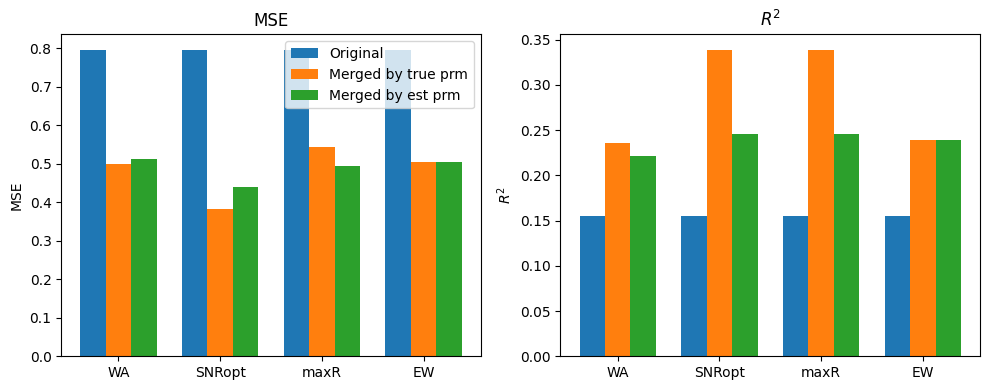

In [6]:
MSE_results = np.vstack([
    np.mean(MSE_ori) * np.ones(4),
    MSE_true,
    MSE_est
])

R2_results = np.vstack([
    np.mean(R2_ori) * np.ones(4),
    R2_true,
    R2_est
])

methods = ['WA', 'SNRopt', 'maxR', 'EW']
xpos = np.arange(len(methods))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# MSE
axes[0].bar(xpos - width, MSE_results[0], width, label='Original')
axes[0].bar(xpos,         MSE_results[1], width, label='Merged by true prm')
axes[0].bar(xpos + width, MSE_results[2], width, label='Merged by est prm')
axes[0].set_ylabel('MSE')
axes[0].set_title('MSE')
axes[0].set_xticks(xpos)
axes[0].set_xticklabels(methods)
axes[0].legend()

# R2
axes[1].bar(xpos - width, R2_results[0], width, label='Original')
axes[1].bar(xpos,         R2_results[1], width, label='Merged by true prm')
axes[1].bar(xpos + width, R2_results[2], width, label='Merged by est prm')
axes[1].set_ylabel(r'$R^2$')
axes[1].set_title(r'$R^2$')
axes[1].set_xticks(xpos)
axes[1].set_xticklabels(methods)

plt.tight_layout()
plt.show()
